# Generador de archivos ROOT con valores de $\frac{dR}{dE}$ para las diferentes librerias

OJO - La primera vez que se ejecuta este notebook se recomienda leer y revisar paso por paso, una vez se tenga todo seguro ya se puede ejecutar todo de vez.

### IMPORTS

In [1]:
import sys            # módulo para interactuar con el intérprete
import os             # módulo para operaciones del sistema de archivos
import numpy as np    # librería numérica
import matplotlib.pyplot as plt  # para crear gráficos
import math as m


from scipy import special
from scipy.stats import norm


Este código tiene como objetivo calcular el ritmo diferencial esperado en el detector empleando diferentes librerías.

## Instalación de librerías

En primer lugar tenemos que instalar/compilar los paquetes RAPIDD y WIMPYDD, cada una de ellas tiene sus particularidades y su instalación es diferente para cada sistema operativo. Lo que nos interesa es la ruta de instalación, ya que es lo que necesita el código para ubicarlas y poder trabajar con ellas.

En este ejemplo las vamos a instalar en la carpeta: "/libs" por lo que emplearemos la ruta relativa desde la ubicación del archivo. En caso de instalarlos en otra ubicación deberemos usar la ruta absoluta de la carpeta.

In [ ]:
#Ruta de la carpeta donde se encuentra el codigo ANAIS
ANAIS_rel_path = 'Libs/ANAIS'


ANAIS_abs_path = os.path.realpath("../GeneraRitmo/Libs/ANAIS")   
sys.path.append(ANAIS_abs_path)
print(ANAIS_abs_path)

/home/borja/Documents/TFG/GeneraRitmo/Libs/ANAIS


## Importamos las librerías necesarias

Procedemos a incorporar las librerías al código y de esta forma poder usar sus funciones.

In [3]:
#Importamos ANAIS

from funciones_ritmo_teorico import*
from funciones_ritmo_exp import*

In [4]:

mw_arr = []
for imw in range(2, 10):      # 5, 6, 7, 8, 9
    for j in range (4):
        a=imw+0.2*j
        mw_arr.append(a)

for imw in range(1, 10):
    for j in range (4):
        a=imw+0.2*j
        mw_arr.append(a * 10)

for imw in range(1, 10):
    for j in range (4):
        a=imw+0.2*j     # 1, 2, …, 10
        mw_arr.append(a * 100)

for imw in range(1, 11):
    for j in range (4):
        a=imw+0.2*j
        mw_arr.append(a * 1000)

print(len(mw_arr))
print(mw_arr)
mw_arr=np.array(mw_arr)
mw_arr=np.round(mw_arr,1)
print(mw_arr)

144
[2.0, 2.2, 2.4, 2.6, 3.0, 3.2, 3.4, 3.6, 4.0, 4.2, 4.4, 4.6, 5.0, 5.2, 5.4, 5.6, 6.0, 6.2, 6.4, 6.6, 7.0, 7.2, 7.4, 7.6, 8.0, 8.2, 8.4, 8.6, 9.0, 9.2, 9.4, 9.6, 10.0, 12.0, 14.0, 16.0, 20.0, 22.0, 24.0, 26.0, 30.0, 32.0, 34.0, 36.0, 40.0, 42.0, 44.0, 46.0, 50.0, 52.0, 54.0, 56.0, 60.0, 62.0, 64.0, 66.0, 70.0, 72.0, 74.0, 76.0, 80.0, 82.0, 84.0, 86.0, 90.0, 92.0, 94.0, 96.0, 100.0, 120.0, 140.0, 160.0, 200.0, 220.00000000000003, 240.0, 260.0, 300.0, 320.0, 340.0, 360.0, 400.0, 420.0, 440.00000000000006, 459.99999999999994, 500.0, 520.0, 540.0, 560.0, 600.0, 620.0, 640.0, 660.0, 700.0, 720.0, 740.0, 760.0, 800.0, 819.9999999999999, 840.0, 860.0, 900.0, 919.9999999999999, 940.0, 960.0, 1000.0, 1200.0, 1400.0, 1600.0, 2000.0, 2200.0, 2400.0, 2600.0, 3000.0, 3200.0, 3400.0, 3600.0, 4000.0, 4200.0, 4400.0, 4600.0, 5000.0, 5200.0, 5400.0, 5600.0, 6000.0, 6200.0, 6400.0, 6600.0, 7000.0, 7200.0, 7400.0, 7600.0, 8000.0, 8200.0, 8400.0, 8600.0, 9000.0, 9200.0, 9400.0, 9600.0, 10000.0, 10200.0

# Generamos los datos del ritmo diferencial

Primero generamos una lista de masas de wimp entre 2 valores preestablecidos en escala logarítmica

In [5]:
#Numero de puntos del plot
#n_masas=150

#Valor mínimo de masa
#masa_min=3

#Valor máximo de masa
#masa_max=1.75e04

#array_masas=np.geomspace(masa_min,masa_max,n_masas)
array_masas=mw_arr
#print(array_masas)

Generamos un array con los diferentes valores de energía para el plot de ritmo diferencial. 

In [6]:
#Numero de puntos del plot
n_energias=1000

#Valor mínimo de masa
energias_min=0

#Valor máximo de masa
energias_max=100

energies = np.linspace(energias_min,energias_max,n_energias)

Establecemos el valor de seccion eficaz (1 cm² por defecto)

In [7]:
#sección eficaz SI(cm^-2)
si=1e-36                               

In [8]:
matriz_DMA_Na=np.zeros((len(array_masas),len(energies)))
matriz_DMA_I=np.zeros((len(array_masas),len(energies)))
for i in range (len(mw_arr)):
    mW=mw_arr[i]
    name2="rateDMAnalysis_SI_separados.root"
    file = uproot.open(name2)
    name="SI_rates/rate_SI_"
    name+="Na"
    name+="_mw"
    name+=str(np.round(mW,1))
    hist = file[name]
    bin_content = hist.values()
    data_Na = np.array(bin_content)
    bin_centers = hist.axis().centers()
    ene_Na = np.array(bin_centers)

    name2="rateDMAnalysis_SI_separados.root"
    file = uproot.open(name2)
    name="SI_rates/rate_SI_"
    name+="I"
    name+="_mw"
    name+=str(np.round(mW,1))
    hist = file[name]
    bin_content = hist.values()
    data_I = np.array(bin_content)
    bin_centers = hist.axis().centers()
    ene_I = np.array(bin_centers)

    matriz_DMA_I[i]=data_I
    matriz_DMA_Na[i]=data_Na

### ANAIS

## Generar el archivo .root con los histogramas

Genera un histograma de 1000 bines de nombre "hist_mw_xxxxx.xx" para cada masa de Wimp con el ritmo diferencial desde 0 a 100 keV_ee y los guarda todos en un mismo archivo de root llamado 

In [9]:
import ROOT
import numpy as np
import uproot

def Guarda_root(histNa,histI,mw,filename):
   rel_path = "Results/"
   abs_path = os.path.realpath(rel_path) 
   myFile = ROOT.TFile.Open(abs_path+"/"+filename, "RECREATE")

   for i in range(len(histNa)):  
      nombre="hist_Na_mw_"
      nombre=nombre+str(np.round(mw[i],2))
      h = ROOT.TH1D(nombre, nombre+"_h", 1000, 0, 100)
      for j in range(len(histNa[0])):
         h.SetBinContent(j+1,histNa[i][j])
      myFile.WriteObject(h, nombre)
   for i in range(len(histI)):  
      nombre="hist_I_mw_"
      nombre=nombre+str(np.round(mw[i],2))
      h = ROOT.TH1D(nombre, nombre+"_h", 1000, 0, 100)
      for j in range(len(histI[0])):
         h.SetBinContent(j+1,histI[i][j])
      myFile.WriteObject(h, nombre)
   # At the end of the function, there are no more references to `file`.
   # The `TFile` object gets deleted, which in turn saves and closes
   # the ROOT file.



Guarda_root(matriz_DMA_Na,matriz_DMA_I,array_masas,"DMA_SI_TH1D.root")

/home/borja/anaconda3/lib/python3.9/site-packages/ROOT/__init__.py:5: UserWarning: 
This distribution of ROOT is in alpha stage. Feedback is welcome and appreciated. Feel free to reach out to the user forum for questions and general feedback at https://root-forum.cern.ch or to submit an issue at https://github.com/root-project/root/issues. Do not rely on this distribution for production purposes.

  warnings.warn(
/home/borja/anaconda3/lib/python3.9/site-packages/cppyy/__init__.py:374: UserWarning: CPyCppyy API not found (tried: /home/borja/anaconda3/include/site/python3.9); set CPPYY_API_PATH envar to the 'CPyCppyy' API directory to fix
  warnings.warn("CPyCppyy API not found (tried: %s); "


### Genera lista con los nombres de los histogramas

### Comprueba que se han guardado los histogramas correctamente en el archivo root

In [10]:
import ROOT
import numpy as np
import uproot
file = uproot.open("Results/DMA_SI_TH1D.root")
file2 = uproot.open("Results/DMA_SI_TH1D.root")
#file.keys()


In [11]:
y_Na=file["hist_Na_mw_10.0"].values()
x_Na=np.arange(0,100,(100/len(y_Na)))
print(len(x_Na))
print(len(y_Na))

y_I=file["hist_I_mw_10.0"].values()
x_I=np.arange(0,100,(100/len(y_I)))
print(len(x_I))
print(len(y_I))

1000
1000
1000
1000


In [12]:
y_Na2=file2["hist_Na_mw_10.0"].values()
x_Na2=np.arange(0,100,(100/len(y_Na2)))
print(len(x_Na2))
print(len(y_Na2))

y_I2=file2["hist_I_mw_10.0"].values()
x_I2=np.arange(0,100,(100/len(y_I2)))
print(len(x_I2))
print(len(y_I2))

1000
1000
1000
1000


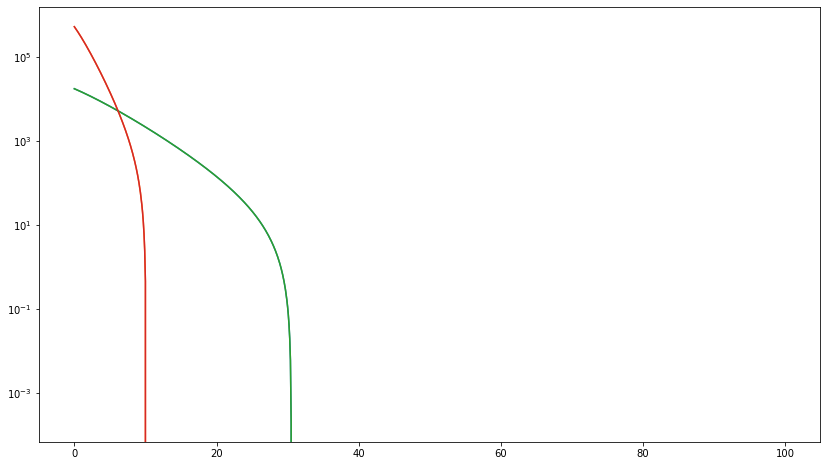

In [13]:
plt.figure(figsize=(14, 8))
ax = plt.subplot()
ax.set_yscale("log")
#ax.set_xscale("log")

plt.plot(x_Na,y_Na,label="Na")
plt.plot(x_I,y_I,label="I")

plt.plot(x_Na2,y_Na2,label="Na2")
plt.plot(x_I2,y_I2,label="I2")

#print(y)